# Cold Start Analysis

## Objective
- Simulate scenarios where a new user has rated few and/or no items.
- Explain and offer alternative strategies to mitigate cold starts.
- Provide performance analysis and visualizations for each alternative cold start scenario.

## Alternative Strategies

### 1. Demographic-Based Recommendations
- **Approach**: This method relies on user demographic data (e.g., age, gender, occupation) to generate recommendations.

- **How it works**: Users are grouped by their demographic profiles, and recommendations are made based on the average ratings of other users in the same group.

- **Advantages**: Quick and easy to implement when user-item interactions are sparse.

- **Cold Start Mitigation**: 
    - When a new user does not have enough interactions, the recommender system can still generate ratings by using the demographic-based model.

    - This allows the system to offer relevant recommendations based on the new user's demographics, ensuring that they receive a meaningful starting point.
  
### 2. Hybrid Content-Profile Filtering
- **Approach**: Combines content-based filtering with demographic-based filtering to predict ratings for new users.

- **How it works**: The system uses item features (genres, tags) combined with the user demographic information to generate recommendations. For new users who have limited interaction history, the system can generate a reasonable recommendation based on their demographics and known preferences of similar demographic groups.

- **Advantages**: More robust than demographic-only methods as it combines content features with user profile data.

- **Cold Start Mitigation**: 
    - In case of new users, demographic-based features are used to create a user profile, and items are recommended based on similarity to other users in the same demographic group.
    
    - The content-based filtering aspect provides item features that can be leveraged even with minimal interactions from the user.
  
### 3. Collaborative Filtering
- **Approach**: Collaborative filtering uses past user-item interactions (ratings) to predict ratings for new items and users.

- **How it works**: The system uses matrix factorization techniques (e.g., SVD) to learn patterns from user-item interactions. It predicts the rating a user might give to an item based on the interactions of similar users.

- **Advantages**: Very effective when user-item interaction data is plentiful. It can generate recommendations that reflect the community's preferences.

- **Cold Start Mitigation**: 
    - **For new users**: Collaborative filtering struggles as it requires a history of interactions. However, it can be combined with demographic or content-based features to address this issue by relying on similar users' behavior or item features.

    - **For new items**: This can be mitigated by combining with content-based filtering, where items are recommended based on their features and similarity to previously rated items.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
from collections import defaultdict
from surprise import SVD

import sys
sys.path.append('..')

from pipeline import Pipeline
from modules.adaptive.filters.rule_based import RuleBasedFiltering
from modules.adaptive.filters.collaborative import CollaborativeFiltering
from modules.adaptive.filters.content_based import ContentBasedFiltering
from modules.demographic_recommender import DemographicRecommender
from modules.hybrid import HybridContentProfileRecommender

# Helper Functions
def ndcg_at_k(y_true, y_pred, k=None):
    if k is None:
        k = len(y_true)
    
    sorted_indices = np.argsort(-np.array(y_pred))[:k]
    y_true_sorted = np.array(y_true)[sorted_indices]
    
    dcg = np.sum((2 ** y_true_sorted - 1) / np.log2(np.arange(1, len(y_true_sorted) + 1) + 1))
    
    ideal_sorted = np.sort(y_true)[::-1][:k]
    idcg = np.sum((2 ** ideal_sorted - 1) / np.log2(np.arange(1, len(ideal_sorted) + 1) + 1))
    
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_recommender(recommender, test_df, k=10):
    true_ratings = []
    predicted_ratings = []
    grouped = test_df.groupby("user_id")
    
    for user_id, group in grouped:
        for _, row in group.iterrows():
            user_id = row["user_id"]
            item_id = row["movie_id"]
            true_rating = row["rating"]
            
            predicted_rating = recommender.predict(user_id, item_id)
            
            true_ratings.append(true_rating)
            predicted_ratings.append(predicted_rating)
    
    if any(pd.isna(predicted_ratings)):
        nan_in_predicted = [i for i, val in enumerate(predicted_ratings) if pd.isna(val)]
        print(f"NaN in predicted_ratings at indices: {nan_in_predicted}")
        predicted_ratings = [0 if pd.isna(val) else val for val in predicted_ratings]

    # Compute RMSE
    rmse = np.sqrt(mean_squared_error(true_ratings, predicted_ratings))
    
    # Compute MAE
    mae = mean_absolute_error(true_ratings, predicted_ratings)
    
    # Compute nDCG
    ndcg_scores = []
    for user_id, group in grouped:
        y_true = group["rating"].tolist()
        y_pred = [recommender.predict(user_id, item_id) for item_id in group["movie_id"]]
        ndcg_scores.append(ndcg_at_k(y_true, y_pred, k))
    
    ndcg = np.mean(ndcg_scores)
    
    return rmse, mae, ndcg

def plot_results(results):
    results_df = pd.DataFrame(results)

    plt.figure(figsize=(10, 5))
    results_df.set_index('Model')[['RMSE', 'MAE', 'NDCG']].plot(kind='bar', figsize=(10, 6))
    plt.title('Model Performance Comparison')
    plt.ylabel('Score')
    plt.xlabel('Model')
    plt.xticks(rotation=45)
    plt.show()

# Baseline recommender that always returns a fixed rating (3)
class BaselineRecommender:
    def __init__(self, fixed_rating=3):
        self.fixed_rating = fixed_rating

    def predict(self, user_id, item_id):
        return self.fixed_rating

In [2]:
pipeline = Pipeline()
ratings_df = pipeline.load_data('../storage/u.data') 
train_df, test_df = pipeline.partition_data(ratings_df, partition_type='stratified', save_path='../storage', data_name='stratified')

# Check if user IDs from train are in test
train_user_ids = train_df['user_id'].unique()
test_user_ids = test_df['user_id'].unique()
common_user_ids = set(train_user_ids).intersection(test_user_ids)

print(f"Number of unique users in train: {len(train_user_ids)}")
print(f"Number of unique users in test: {len(test_user_ids)}")
print(f"Number of users common between train and test: {len(common_user_ids)}")

if len(common_user_ids) == 0:
    print("No user IDs from test are in the train dataset.")

Dataset loaded successfully.
Dataset Shape: (100000, 4)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB
None

First few rows:
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596
Number of unique users in train: 754
Number of unique users in test: 189
Number of users common between train and test: 0
No user IDs from test are in the train dataset.


Performance for of the Temporal Partitioned Data:


<Figure size 1000x500 with 0 Axes>

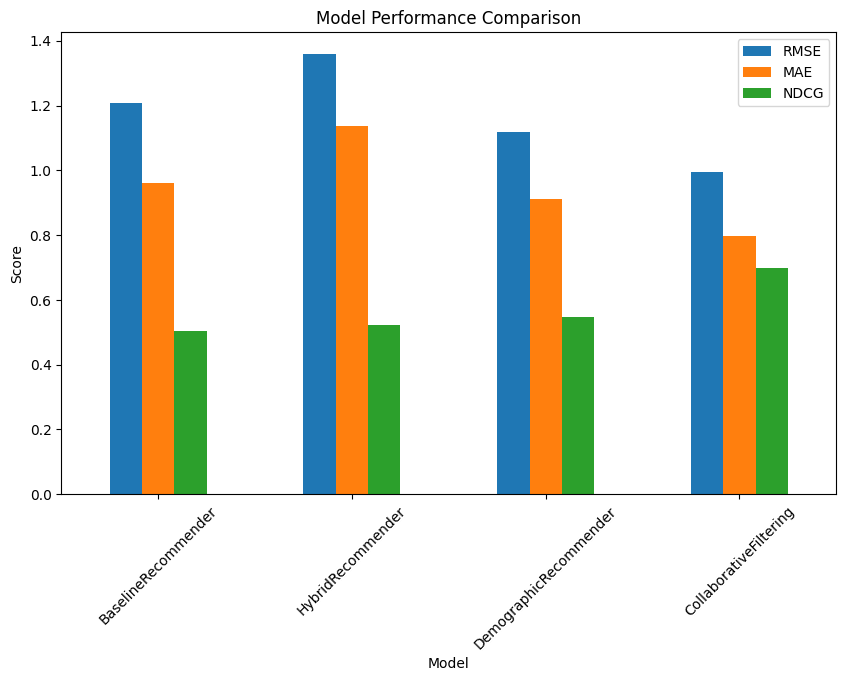

In [3]:
metadata_file='../storage/u.item'
user_file='../storage/u.user'
ratings_file='../storage/train/stratified'

demographic_recommender = DemographicRecommender(
        ratings_file=ratings_file,
        user_file=user_file,
        item_file=metadata_file,
)
demographic_recommender.fit()

hybrid_recommender = HybridContentProfileRecommender(
        ratings_file=ratings_file,
        user_file=user_file,
        item_file=metadata_file,
)

svd_params = {'n_factors': 200, 'n_epochs': 100, 'lr_all': 0.01, 'reg_all': 0.1}
collaborative_recommender = CollaborativeFiltering(
        ratings_file=ratings_file,
        metadata_file=metadata_file,
        algorithm=SVD(**svd_params)
    )
collaborative_recommender.fit()

models = {
    'BaselineRecommender': BaselineRecommender(fixed_rating=3),
    'HybridRecommender': hybrid_recommender,
    'DemographicRecommender': demographic_recommender,
    'CollaborativeFiltering': collaborative_recommender
}

results = defaultdict(list)

for name, model in models.items():
    rmse, mae, ndcg = evaluate_recommender(model, test_df)
    results['Model'].append(name)
    results['RMSE'].append(rmse)
    results['MAE'].append(mae)
    results['NDCG'].append(ndcg)

print('Performance for of the Temporal Partitioned Data:')
plot_results(results)

## Analysis

### 1. Demographic-Based Recommendations
- **Performance**: Demographic-based recommendations work better than the baseline and hybrid methods, but slightly worse than collaborative filtering. It can provide instant recommendations without needing any prior ratings. However, these recommendations may not be very personalized, as they are based on the average preferences of similar demographic groups.

### 2. Hybrid Content-Profile Filtering
- **Performance**: Hybrid models perform worse than the baseline, which simply sets all ratings to 3. The new user's demographic info helps create a basic profile, and the content-based method uses item features to suggest relevant items, but overall, it doesn't outperform the baseline.

### 3. Collaborative Filtering with Cold Start
- **Performance**: Collaborative filtering performs the best overall because it focuses on user-item interactions. The model can identify patterns in ratings across a large user base, even if a user has rated only a few items. By adding demographic or content-based methods, collaborative filtering can handle cold start problems better. It fills in the gaps by using information about the user (like age or occupation) or item features (like genre) to make recommendations more relevant and accurate for new users, which helps improve the overall performance.

## Conclusion
In conclusion, while all cold start strategies have their strength, demographic-based recommendations offer a quick solution by using user demographics to suggest items, though they lack personalization. Hybrid content-profile filtering, while combining demographic and item feature data, performs worse than the baseline method and doesn't provide significant improvements. Collaborative filtering, on the other hand, performs the best. Combining collaborative filtering with demographic or content-based methods can help mitigate these challenges and improve performance.